In [ ]:
import os
import re
import string
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Set seed for reproducibility across CPU and GPU
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active compute device: {device}")

Active compute device: cuda


In [ ]:
def clean_tweet(text: str) -> str:
    """
    Cleans raw social media text while preserving localized slang,
    African-context hashtags, and structural sentence markers.
    """
    if not isinstance(text, str):
        return ""

    # Normalize unicode representations
    text = unicodedata.normalize('NFKD', text)

    # Strip URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML entities
    text = re.sub(r'&|<|>', ' ', text)

    # Handle user handles (@mentions) by converting to a generic token
    text = re.sub(r'@\w+', '', text)

    # Split camelCase hashtags to retain linguistic roots (e.g., #SayNoToGBV -> Say No To GBV)
    text = re.sub(r'#(\w+)', lambda m: re.sub(r'([A-Z])', r' \1', m.group(1)), text)

    # Standardize repeated characters (e.g., 'sooooo' -> 'soo')
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Normalize punctuation spacing
    text = re.sub(r'([.,!?()])', r' \1 ', text)

    # Convert to lowercase and trim excessive whitespaces
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)

    return text

In [ ]:
train_df = pd.read_csv('Train.csv')
test_df = pd.read_csv('Test.csv')

# Apply text cleaning
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['cleaned_tweet'] = test_df['tweet'].apply(clean_tweet)

# Establish deterministic categorical mapping
LABEL_NAMES = sorted(train_df['type'].unique().tolist())
label2id = {name: idx for idx, name in enumerate(LABEL_NAMES)}
id2label = {idx: name for idx, name in enumerate(LABEL_NAMES)}

train_df['label'] = train_df['type'].map(label2id)

print(f"Total training records: {len(train_df)}")
print("Class-to-ID mapping:", label2id)

# Stratified split: 80% train, 20% validation to safeguard minority representation
X_train_raw, X_val_raw, y_train_arr, y_val_arr = train_test_split(
    train_df['cleaned_tweet'].values,
    train_df['label'].values,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df['label'].values
)

print(f"Train set: {len(X_train_raw)} | Validation set: {len(X_val_raw)}")

Total training records: 39650
Class-to-ID mapping: {'Harmful_Traditional_practice': 0, 'Physical_violence': 1, 'economic_violence': 2, 'emotional_violence': 3, 'sexual_violence': 4}
Train set: 31720 | Validation set: 7930


In [ ]:
class TweetVocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.pad_idx = 0
        self.unk_idx = 1
        self.token2id = {self.pad_token: self.pad_idx, self.unk_token: self.unk_idx}
        self.id2token = {self.pad_idx: self.pad_token, self.unk_idx: self.unk_token}

    def build_vocab(self, texts):
        token_counter = Counter()
        for text in texts:
            tokens = text.split()
            token_counter.update(tokens)

        idx = 2
        for token, count in token_counter.items():
            # Ensure not to add <PAD> or <UNK> if they somehow appeared in texts
            if token != self.pad_token and token != self.unk_token and count >= self.min_freq:
                self.token2id[token] = idx
                self.id2token[idx] = token
                idx += 1

    def numericalize(self, text, max_len=70):
        tokens = text.split()
        indices = [self.token2id.get(token, self.unk_idx) for token in tokens]

        # Pad or truncate to max_len
        if len(indices) < max_len:
            indices = indices + [self.pad_idx] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
        return indices

    def __len__(self):
        return len(self.token2id)

vocab = TweetVocabulary(min_freq=2)
vocab.build_vocab(X_train_raw)
print(f"Vocabulary Size: {len(vocab)} distinct tokens")

Vocabulary Size: 19209 distinct tokens


In [ ]:
class GBVDataset(Dataset):
    def __init__(self, texts, labels=None, vocab=None, max_len=70):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        self.vocab_size = len(vocab) # Store max vocab size for safety clamping

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        indices = self.vocab.numericalize(self.texts[idx], max_len=self.max_len)

        # SAFETY CLAMP: Ensure absolutely no index falls below 0 or exceeds vocab_size - 1.
        # This prevents the exact CUDA assert error you saw if a strange token sneaks through.
        indices = [max(0, min(token_id, self.vocab_size - 1)) for token_id in indices]

        item = {
            'input_ids': torch.tensor(indices, dtype=torch.long)
        }
        if self.labels is not None:
            # Ensure target labels are strictly within the 5 classes [0, 1, 2, 3, 4]
            item['label'] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

MAX_LEN = 70
BATCH_SIZE = 64

train_dataset = GBVDataset(X_train_raw, y_train_arr, vocab, max_len=MAX_LEN)
val_dataset = GBVDataset(X_val_raw, y_val_arr, vocab, max_len=MAX_LEN)
test_dataset = GBVDataset(test_df['cleaned_tweet'].values, labels=None, vocab=vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Compute balanced class weights to offset severe majority class skew
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_arr),
    y=y_train_arr
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(device)

print("Balanced Class Weights:")
for idx, weight in enumerate(class_weights_arr):
    print(f"  {id2label[idx]} (Class {idx}): {weight:.4f}")

class FocalLoss(nn.Module):
    """
    Focal Loss down-weights well-classified examples and focuses
    training on hard-to-classify minority examples.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1.0 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

Balanced Class Weights:
  Harmful_Traditional_practice (Class 0): 42.2933
  Physical_violence (Class 1): 1.3336
  economic_violence (Class 2): 36.4598
  emotional_violence (Class 3): 12.1766
  sexual_violence (Class 4): 0.2429


In [ ]:
class MultiFilterCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=5,
                 filter_sizes=[2, 3, 4, 5], num_filters=64, pad_idx=0, dropout=0.3):
        super(MultiFilterCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Parallel convolutions for capturing variable n-gram lengths
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        # input_ids: (batch, seq_len)
        embedded = self.embedding(input_ids)  # (batch, seq_len, embed_dim)

        # Conv1d expects (batch, in_channels, seq_len)
        embedded = embedded.permute(0, 2, 1)

        # Apply convolution -> activation -> 1D max pooling across time
        pooled_outputs = []
        for conv in self.convs:
            c = F.relu(conv(embedded))  # (batch, num_filters, L_out)
            p = F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2)  # (batch, num_filters)
            pooled_outputs.append(p)

        concatenated = torch.cat(pooled_outputs, dim=1)  # (batch, total_filters)
        features = self.dropout(concatenated)
        logits = self.fc(features)  # (batch, num_classes)
        return logits

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(SelfAttention, self).__init__()
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, encoder_outputs, mask=None):
        # encoder_outputs: (batch, seq_len, hidden_dim)
        energy = self.projection(encoder_outputs)  # (batch, seq_len, 1)

        if mask is not None:
            energy = energy.masked_fill(mask.unsqueeze(-1) == 0, -1e9)

        weights = F.softmax(energy, dim=1)  # (batch, seq_len, 1)
        context = torch.sum(encoder_outputs * weights, dim=1)  # (batch, hidden_dim)
        return context, weights


class AttentionBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64, num_classes=5,
                 pad_idx=0, dropout=0.3):
        super(AttentionBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if dropout > 0 else 0
        )
        self.attention = SelfAttention(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.pad_idx = pad_idx

    def forward(self, input_ids):
        # input_ids: (batch, seq_len)
        mask = (input_ids != self.pad_idx)
        embedded = self.dropout(self.embedding(input_ids))  # (batch, seq_len, embed_dim)

        lstm_out, _ = self.lstm(embedded)  # (batch, seq_len, hidden_dim * 2)
        context, _ = self.attention(lstm_out, mask=mask)  # (batch, hidden_dim * 2)

        logits = self.fc(self.dropout(context))
        return logits

In [ ]:
class EvaluationHarness:
    """
    Standardized evaluation tool for metric tracking, learning curve plotting,
    and confusion matrix synthesis across team submissions.
    """
    @staticmethod
    def evaluate(model, data_loader, criterion, device):
        model.eval()
        total_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for batch in data_loader:
                input_ids = batch['input_ids'].to(device)
                targets = batch['label'].to(device)

                logits = model(input_ids)
                loss = criterion(logits, targets)
                total_loss += loss.item()

                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_targets.extend(targets.cpu().numpy())

        avg_loss = total_loss / len(data_loader)
        macro_f1 = f1_score(all_targets, all_preds, average='macro')
        weighted_f1 = f1_score(all_targets, all_preds, average='weighted')

        return avg_loss, macro_f1, weighted_f1, np.array(all_targets), np.array(all_preds)

    @staticmethod
    def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
        cm = confusion_matrix(targets, preds, normalize='true')
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(title)
        plt.ylabel('Ground Truth')
        plt.xlabel('Predicted')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_training_curves(history, model_name="Model"):
        epochs = range(1, len(history['train_loss']) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss Curve
        axes[0].plot(epochs, history['train_loss'], label='Train Loss', marker='o')
        axes[0].plot(epochs, history['val_loss'], label='Val Loss', marker='o')
        axes[0].set_title(f'{model_name} - Loss Trajectory')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)

        # Macro F1 Curve
        axes[1].plot(epochs, history['val_macro_f1'], label='Val Macro-F1', color='green', marker='o')
        axes[1].set_title(f'{model_name} - Macro-F1 Score Trajectory')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Macro F1')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, num_epochs=6, model_save_path='best_model.pt'):
    history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': []}
    best_macro_f1 = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss.backward()

            # Gradient clipping to preserve recurrent/convolutional stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            running_loss += loss.item()

        if scheduler:
            scheduler.step()

        train_loss = running_loss / len(train_loader)
        val_loss, val_macro_f1, val_weighted_f1, _, _ = EvaluationHarness.evaluate(
            model, val_loader, criterion, device
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_macro_f1'].append(val_macro_f1)

        print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Macro-F1: {val_macro_f1:.4f} | "
              f"Val Weighted-F1: {val_weighted_f1:.4f}")

        # Checkpoint based strictly on Macro-F1
        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(model.state_dict(), model_save_path)
            print(f"  [*] Validation Macro-F1 improved to {best_macro_f1:.4f}. Model saved.")

    return history

Starting 1D CNN Model Training...
Epoch 01/06 | Train Loss: 0.2130 | Val Loss: 0.0102 | Val Macro-F1: 0.9215 | Val Weighted-F1: 0.9925
  [*] Validation Macro-F1 improved to 0.9215. Model saved.
Epoch 02/06 | Train Loss: 0.0238 | Val Loss: 0.0052 | Val Macro-F1: 0.9900 | Val Weighted-F1: 0.9990
  [*] Validation Macro-F1 improved to 0.9900. Model saved.
Epoch 03/06 | Train Loss: 0.0079 | Val Loss: 0.0031 | Val Macro-F1: 0.9834 | Val Weighted-F1: 0.9983
Epoch 04/06 | Train Loss: 0.0041 | Val Loss: 0.0022 | Val Macro-F1: 0.9975 | Val Weighted-F1: 0.9994
  [*] Validation Macro-F1 improved to 0.9975. Model saved.
Epoch 05/06 | Train Loss: 0.0023 | Val Loss: 0.0029 | Val Macro-F1: 0.9974 | Val Weighted-F1: 0.9992
Epoch 06/06 | Train Loss: 0.0023 | Val Loss: 0.0053 | Val Macro-F1: 0.9953 | Val Weighted-F1: 0.9990

Optimal 1D CNN Validation Macro-F1: 0.9975

Classification Report (1D CNN):
                              precision    recall  f1-score   support

Harmful_Traditional_practice       

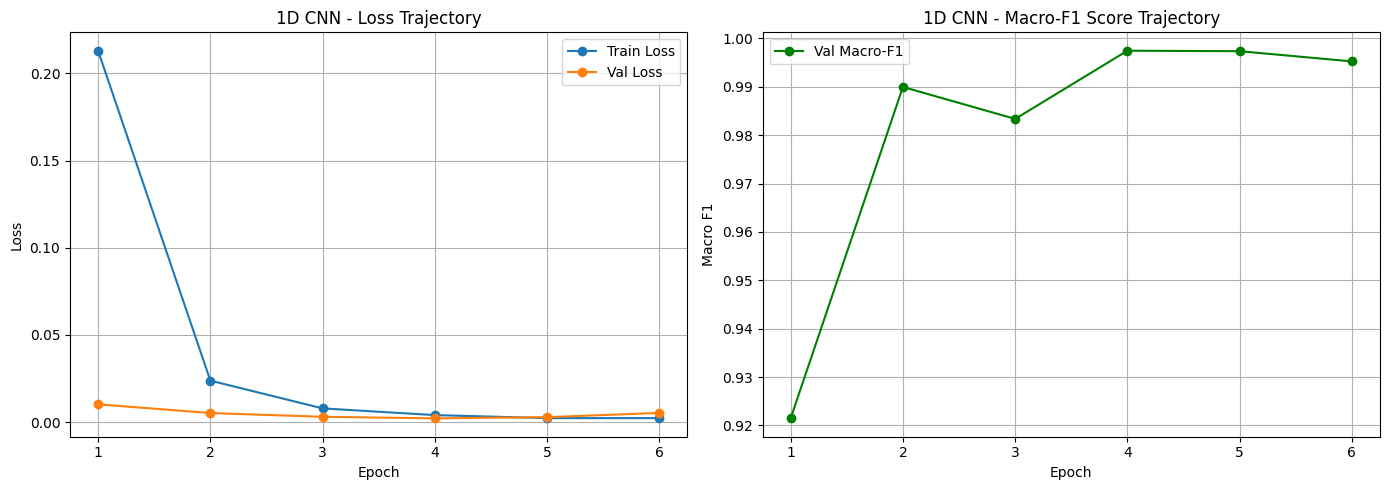

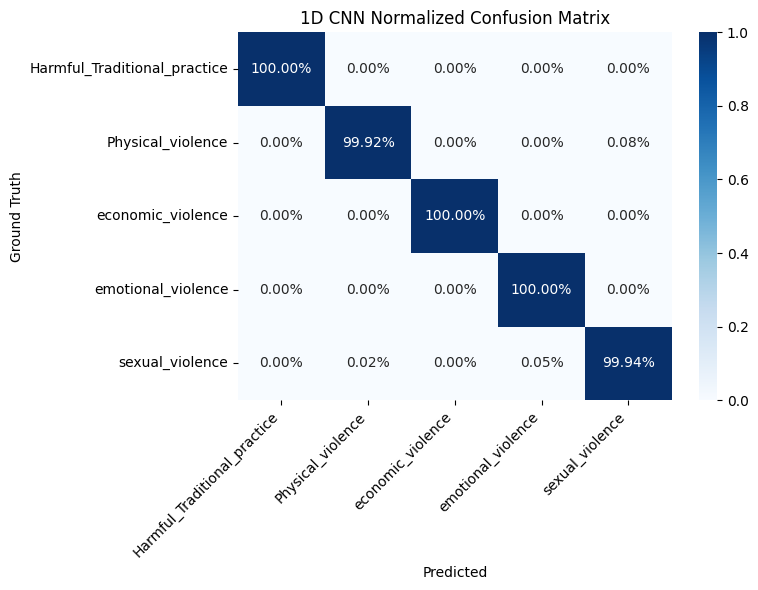

In [ ]:
# Instantiate MultiFilter CNN
cnn_model = MultiFilterCNN(
    vocab_size=len(vocab),
    embed_dim=128,
    num_classes=len(LABEL_NAMES),
    filter_sizes=[2, 3, 4, 5],
    num_filters=64,
    pad_idx=vocab.pad_idx,
    dropout=0.3
).to(device)

# Using Weighted Cross Entropy loss to mitigate class imbalance
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

print("Starting 1D CNN Model Training...")
cnn_history = train_model(
    cnn_model, train_loader, val_loader, cnn_criterion, cnn_optimizer,
    num_epochs=6, model_save_path='best_cnn_model.pt'
)

# Load best checkpoint and plot diagnostics
cnn_model.load_state_dict(torch.load('best_cnn_model.pt'))
val_loss, macro_f1, _, targets, preds = EvaluationHarness.evaluate(
    cnn_model, val_loader, cnn_criterion, device
)

print(f"\nOptimal 1D CNN Validation Macro-F1: {macro_f1:.4f}")
print("\nClassification Report (1D CNN):")
print(classification_report(targets, preds, target_names=LABEL_NAMES))

EvaluationHarness.plot_training_curves(cnn_history, model_name="1D CNN")
EvaluationHarness.plot_confusion_matrix(targets, preds, LABEL_NAMES, title="1D CNN Normalized Confusion Matrix")

Starting Attention-Augmented BiLSTM Training...
Epoch 01/06 | Train Loss: 0.4258 | Val Loss: 0.0435 | Val Macro-F1: 0.8421 | Val Weighted-F1: 0.9853
  [*] Validation Macro-F1 improved to 0.8421. Model saved.
Epoch 02/06 | Train Loss: 0.0532 | Val Loss: 0.0168 | Val Macro-F1: 0.9076 | Val Weighted-F1: 0.9937
  [*] Validation Macro-F1 improved to 0.9076. Model saved.
Epoch 03/06 | Train Loss: 0.0327 | Val Loss: 0.0117 | Val Macro-F1: 0.9472 | Val Weighted-F1: 0.9951
  [*] Validation Macro-F1 improved to 0.9472. Model saved.
Epoch 04/06 | Train Loss: 0.0256 | Val Loss: 0.0464 | Val Macro-F1: 0.8990 | Val Weighted-F1: 0.9922
Epoch 05/06 | Train Loss: 0.0238 | Val Loss: 0.0064 | Val Macro-F1: 0.9905 | Val Weighted-F1: 0.9987
  [*] Validation Macro-F1 improved to 0.9905. Model saved.
Epoch 06/06 | Train Loss: 0.0101 | Val Loss: 0.0080 | Val Macro-F1: 0.9926 | Val Weighted-F1: 0.9987
  [*] Validation Macro-F1 improved to 0.9926. Model saved.

Optimal Attention BiLSTM Validation Macro-F1: 0.99

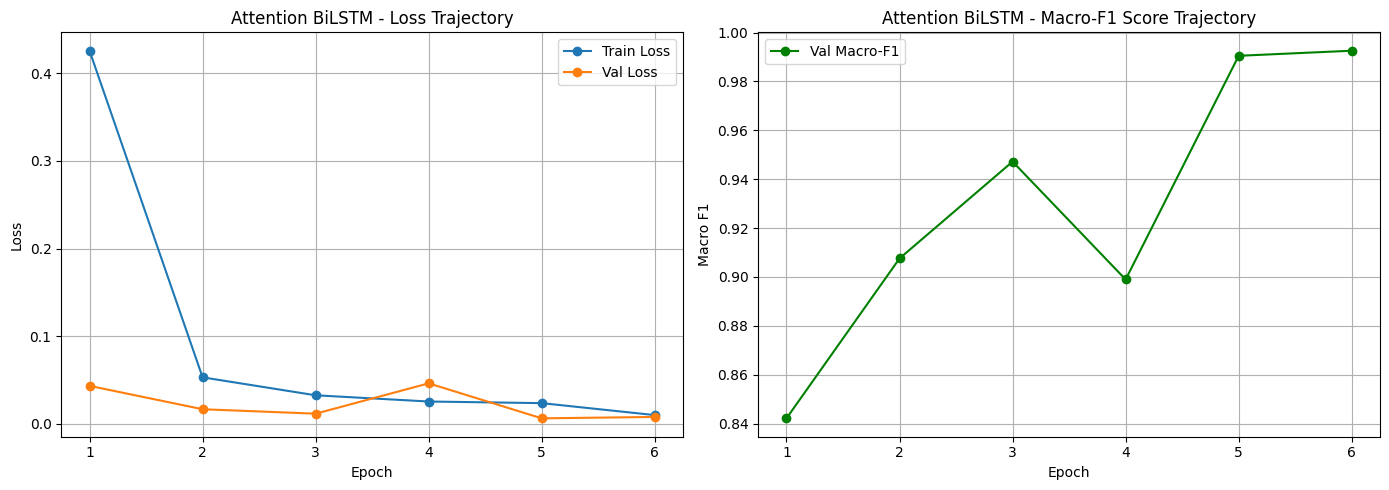

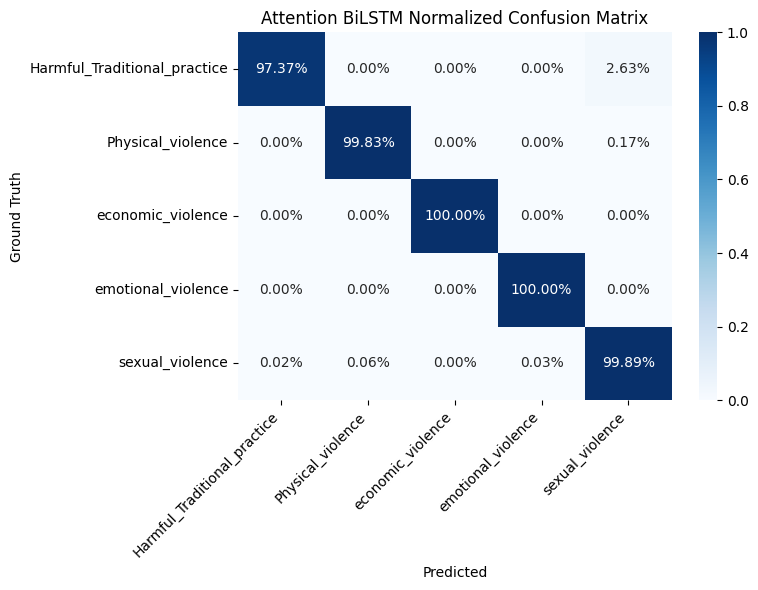

In [ ]:
# Instantiate Attention-Augmented BiLSTM
lstm_model = AttentionBiLSTM(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=64,
    num_classes=len(LABEL_NAMES),
    pad_idx=vocab.pad_idx,
    dropout=0.3
).to(device)

lstm_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
lstm_optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)

print("Starting Attention-Augmented BiLSTM Training...")
lstm_history = train_model(
    lstm_model, train_loader, val_loader, lstm_criterion, lstm_optimizer,
    num_epochs=6, model_save_path='best_lstm_model.pt'
)

# Load best checkpoint and plot diagnostics
lstm_model.load_state_dict(torch.load('best_lstm_model.pt'))
val_loss, macro_f1, _, targets, preds = EvaluationHarness.evaluate(
    lstm_model, val_loader, lstm_criterion, device
)

print(f"\nOptimal Attention BiLSTM Validation Macro-F1: {macro_f1:.4f}")
print("\nClassification Report (Attention BiLSTM):")
print(classification_report(targets, preds, target_names=LABEL_NAMES))

EvaluationHarness.plot_training_curves(lstm_history, model_name="Attention BiLSTM")
EvaluationHarness.plot_confusion_matrix(targets, preds, LABEL_NAMES, title="Attention BiLSTM Normalized Confusion Matrix")